# HOMEWORK 7

In this homework you are going to rectify a document image that suffers from severe distortion. You will be using the same image and the same detected corners from the previous lesson (lesson 6).

Remember, OpenCV documentation is your friend ;-)

At the end of this notebook, there are a couple of questions for you to answer.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image we will be working on in this homework.

(<Axes: >, <matplotlib.image.AxesImage at 0x218a62f6710>)

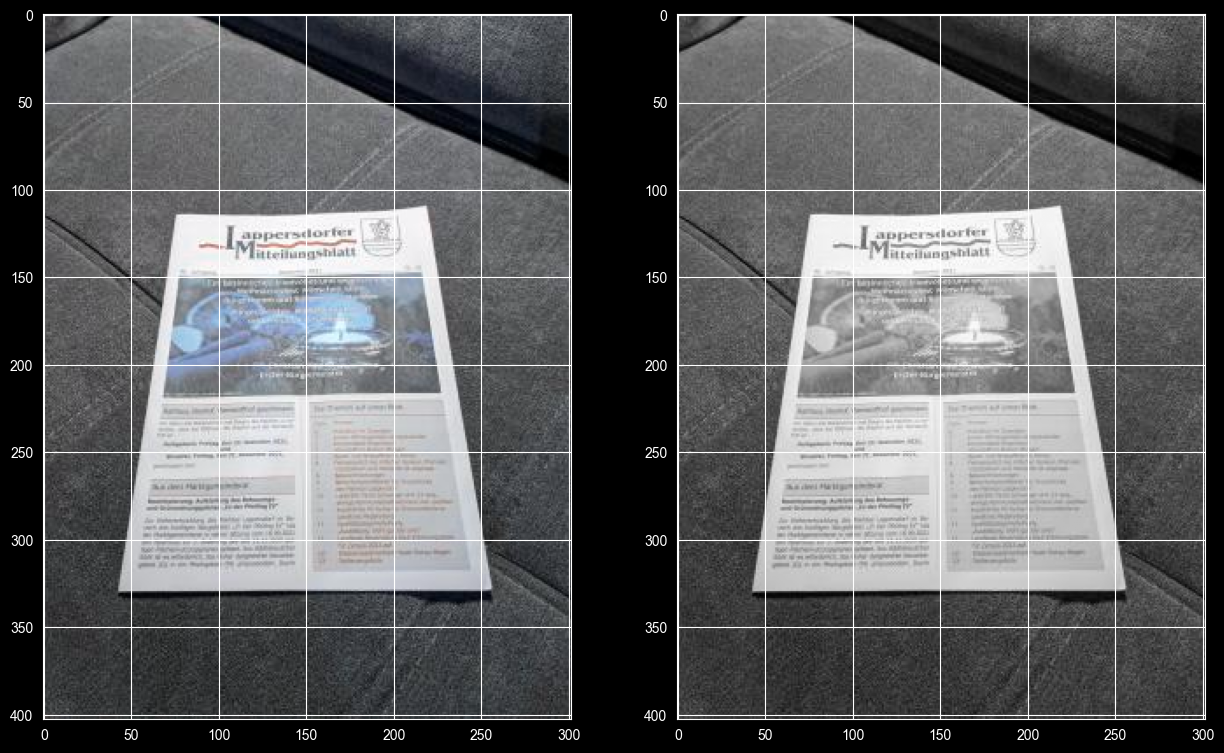

In [2]:
img = cv2.imread('../../lesson_6/data/document_8.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape

# Let's plot the image
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(gray, cmap='gray')

In the previous homework you should have detected the four document corners and you will need to use them here. But don't worry if the previous homework did not work out for you, I am going to provide you with the corners coordinates here :-)

In [3]:
# use implemented methods in CV2 to find corners as bonus task !
# top_left = [76, 115]
# top_right = [219, 111]
# bottom_left = [43, 330]
# bottom_right = [256, 329]

In [4]:
# Compute Harris corners (use the available OpenCV functions)
cornerness = cv2.cornerHarris(gray, # image
                       blockSize=2, # block size of 2 pixels
                       ksize=3, #     gradient kernel size of 3 pixels
                       k=0.04 #       k parameter equal to 0.04
                       )

# We are not interested in edges, so put to zero all negative cornerness values
cornerness[cornerness < 0] = 0

# Since cornerness has a huge dynamic range, let's take the logarithm for better visualization and manipulation
cornerness = np.log(cornerness + 1e-6)

# Detection thresholds
th_top_left, th_top_right = -1e6, -1e6
th_bottom_left, th_bottom_right = -1e6, -1e6

# Corner coordinates
opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None

# Size of each quadrant (in pixels)
quad_size = 7

# Let's now scan the Harris detection results
for r in range(quad_size, rows - quad_size):
    for c in range(quad_size, cols - quad_size):
        # Edges with too small cornerness score are discarded, -7 seems like a good value
        if cornerness[r, c] < -7:
            continue

        # Extract block consisting of 4 quadrants
        block = 255 * gray[r - quad_size:r + quad_size + 1, c-quad_size:c + quad_size + 1]

        # Extract the four quadrants (each is quad_size x quad_size).
        # We ignore the center row/col (the candidate corner pixel) by splitting at quad_size.
        quad_top_left = block[0:quad_size, 0:quad_size]
        quad_top_right = block[0:quad_size, quad_size + 1:]
        quad_bottom_left = block[quad_size + 1:, 0:quad_size]
        quad_bottom_right = block[quad_size + 1:, quad_size + 1:]

        m_tl = np.mean(quad_top_left)
        m_tr = np.mean(quad_top_right)
        m_bl = np.mean(quad_bottom_left)
        m_br = np.mean(quad_bottom_right)

        # Descriptor for each corner: expected 'paper' quadrant mean minus the other three.
        descriptor_tl = m_br - (m_tl + m_tr + m_bl)  # top-left document corner
        descriptor_tr = m_bl - (m_tl + m_tr + m_br)  # top-right document corner
        descriptor_bl = m_tr - (m_tl + m_bl + m_br)  # bottom-left document corner
        descriptor_br = m_tl - (m_tr + m_bl + m_br)  # bottom-right document corner

        # Top-left corner
        if descriptor_tl > th_top_left:
            th_top_left = descriptor_tl
            opt_top_left = (c, r)

        # Top-right corner
        if descriptor_tr > th_top_right:
            th_top_right = descriptor_tr
            opt_top_right = (c, r)

        # Bottom-left corner
        if descriptor_bl > th_bottom_left:
            th_bottom_left = descriptor_bl
            opt_bottom_left = (c, r)

        # Bottom-right corner
        if descriptor_br > th_bottom_right:
            th_bottom_right = descriptor_br
            opt_bottom_right = (c, r)

In [5]:
top_left = opt_top_left
top_right = opt_top_right
bottom_left = opt_bottom_left
bottom_right = opt_bottom_right

(<Axes: >, <matplotlib.image.AxesImage at 0x218a895f890>)

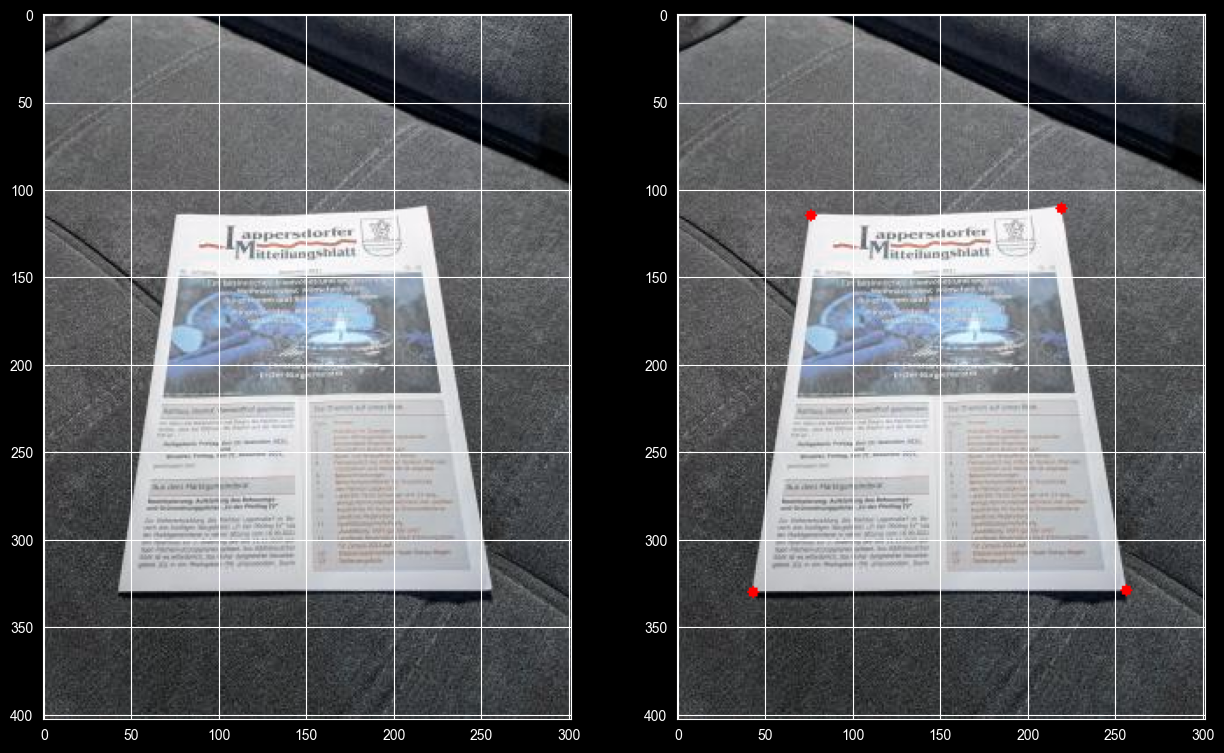

In [6]:
# Let's plot the points
out = np.copy(img)
out = cv2.circle(out, tuple(top_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(top_right), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_right), 3, (255,0,0), -1)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

### Document Rectification

Let's now try to rectify the document. The goal is to bring the four document corners to the image corners. For instance, we want the top-left document corner to become (0, 0), i.e., the top-left corner of the image itself. In that way, we will fill the complete image with document information and we will throw away parts of the images that correspond to background (which are of no use to us).

In [7]:
# Define the matrix of source points corresponding to the 4 document corners.
# The matrix shall have shape (4, 2), i.e., 4 corners x 2 coordinates
# Note: You will need to explicitly use float32 data type

# Option 1 -  Manual mode
x1, y1 = 43, 115
x2, y2 = 256, 330

src = np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)

# Define the matrix of target (destination) points corresponding to the 4 image corners.
# The matrix shall have shape (4, 2), i.e., 4 corners x 2 coordinates
# Note: You will need to explicitly use float32 data type
# Note2: The order of points in src and dst must be the same

w = x2 - x1 # 213
h = y2 - y1 # 215

# Option 2 - Using Math ( Optimal, we search maximum height and width
(tl, tr, br, bl) = src

width_top = np.linalg.norm(tr - tl)
width_bottom = np.linalg.norm(br - bl)
w = int(round(max(width_top, width_bottom)))

height_left = np.linalg.norm(bl - tl)
height_right = np.linalg.norm(br - tr)
h = int(round(max(height_left, height_right)))


dst = np.array(
    [
        [0.0, 0.0], #         top_left
        [w - 1.0, 0.0], #     top_right
        [w - 1.0, h - 1.0], # bottom_right
        [0.0, h - 1.0], #     bottom_left
    ],
    dtype=np.float32,
)

In [8]:
# top_left, top_right
(tl, tr, br, bl) = src

width_top = np.linalg.norm(tr - tl)
width_bottom = np.linalg.norm(br - bl)

# width_top, width_bottom

height_left = np.linalg.norm(bl - tl)
height_right = np.linalg.norm(br - tr)
height_left, height_right

(np.float32(217.51782), np.float32(221.11761))

Let's first start with the affine transform for document rectification. The affine transform can be analytically calculated using 3 point pairs. Therefore, let's select the **first 3 points** and calculate the correspnding transfrom. We will then use the transform to rectify the document.

(<Axes: >, <matplotlib.image.AxesImage at 0x218a8017610>, None)

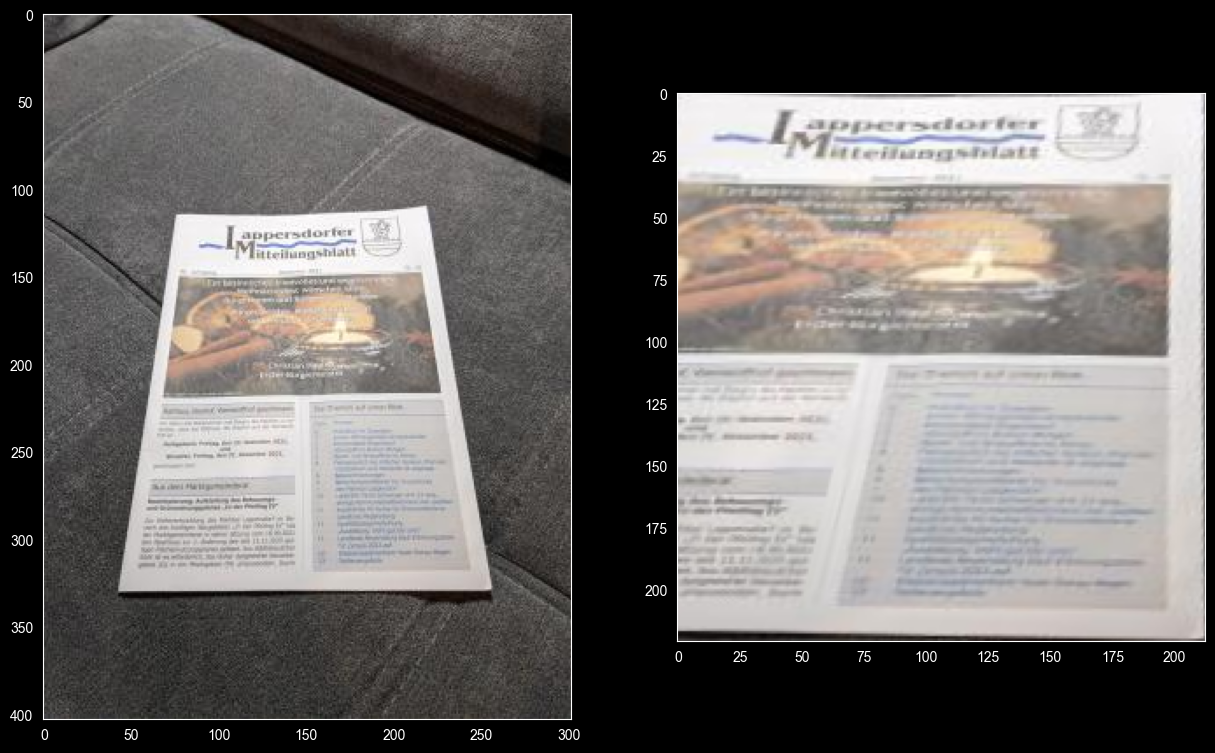

In [9]:
# Compute the affine transform matrix (you'll have to use getAffineTransform function from OpenCV here)
# Use the first 3 points from your src and dst matrix
src3 = src[:3].astype(np.float32)
dst3 = dst[:3].astype(np.float32)

M = cv2.getAffineTransform(src3, dst3)

w = int(np.max(dst[:, 0]) + 1)
h = int(np.max(dst[:, 1]) + 1)

# Build the rectified image using the computed matrix (you'll have to use warpAffine function from OpenCV here)
warped = cv2.warpAffine(img, M, (w, h))

# Let's plot the results
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.grid(False)
plt.subplot(122), plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)), plt.grid(False)

Well, this is not bad by certainly not what we were aiming for. Let's try the **last 3** points instead.

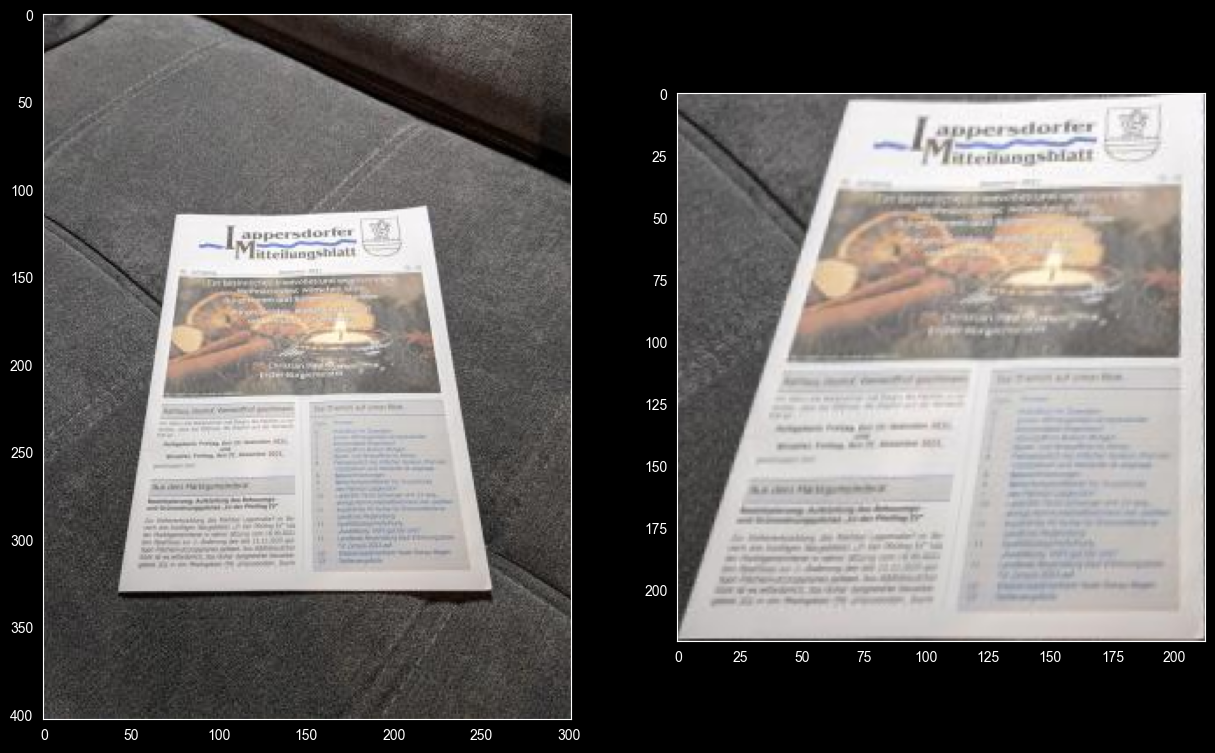

In [10]:
# Compute the affine transform matrix (use getAffineTransform)
# Use the last 3 points from your src and dst matrix

src3 = src[-3:].astype(np.float32)
dst3 = dst[-3:].astype(np.float32)

M = cv2.getAffineTransform(src3, dst3)

# Output size (width, height) derived from dst
w = int(np.max(dst[:, 0]) + 1)
h = int(np.max(dst[:, 1]) + 1)

# Build the rectified image using the computed matrix (use warpAffine)
rectified = cv2.warpAffine(
    img, M, (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(255, 255, 255)  # makes ﷿﷿﷿outside﷿﷿﷿ visible (not black)
)

# Let's plot the results
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.grid(False)
plt.subplot(122), plt.imshow(cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB)), plt.grid(False)
plt.show()

The result looks different but not better. This approach doesn't seem to be helping then. Let's use **all 4 points** and let OpenCV **estimate** (remember that 4 points are too many for an analytical solution) the best fitting affine transform for us. It'll internally apply optimization approaches as well as RANSAC.

(<Axes: >, <matplotlib.image.AxesImage at 0x218a93842d0>, None)

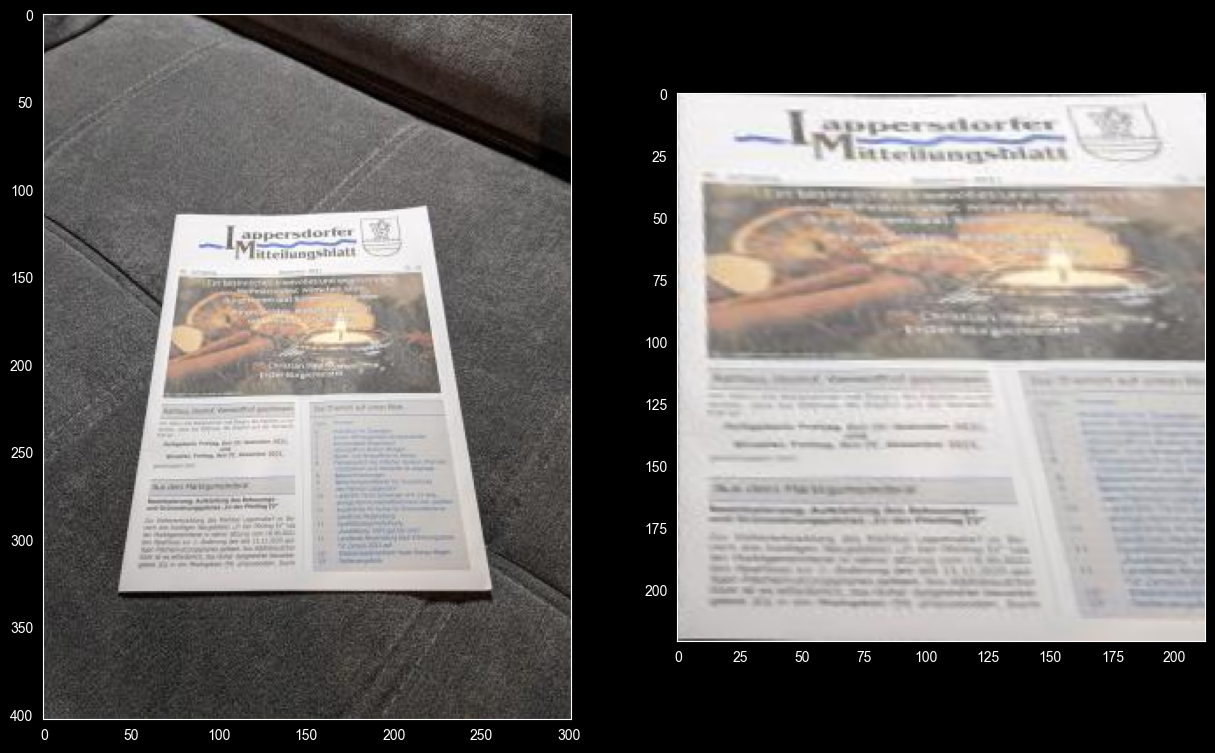

In [11]:
# Estimate the optimal affine transform matrix (you'll have to use estimateAffine2D function from OpenCV here)
# estimateAffine2D it returns the best fitting affine matrix as well as the vector of inliers (1 -> inlier, 0 -> outlier).
M, inliers = cv2.estimateAffine2D(src, dst)

w = int(np.max(dst[:, 0]) + 1)
h = int(np.max(dst[:, 1]) + 1)

# Build the rectified image using the computed matrix (use warpAffine)
rectified = cv2.warpAffine(
    img, M, (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(255, 255, 255),
)

# Let's plot the results
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.grid(False)
plt.subplot(122), plt.imshow(cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB)), plt.grid(False)

There is not much of an improvement either. Let's try homography instead of affine transform. Remember that for computing the homography analytically we need to use 4 pairs of points.

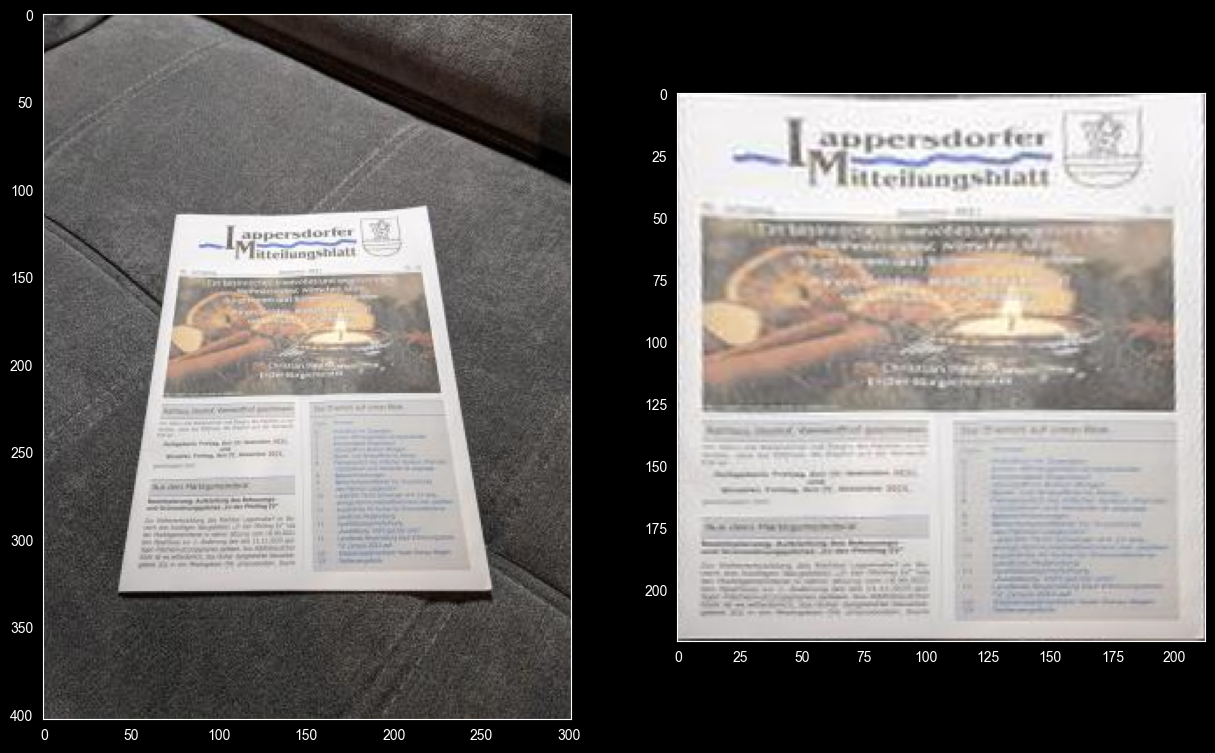

In [12]:
# Compute the homography matrix (you'll have to use getPerspectiveTransform function from OpenCV here)
M = cv2.getPerspectiveTransform(src, dst)

w = int(np.max(dst[:, 0]) + 1)
h = int(np.max(dst[:, 1]) + 1)

# Build the rectified image using the computed matrix (you'll have to use warpPerspective function from OpenCV)
rectified = cv2.warpPerspective(
    img, M, (w, h),
    flags=cv2.INTER_LANCZOS4,
    borderMode=cv2.BORDER_REFLECT101,
    borderValue=(255, 255, 255),
)

# Let's plot the results
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.grid(False)
plt.subplot(122), plt.imshow(cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB)), plt.grid(False)
plt.show()

### Questions
* Q: The affine transform does not seem to be working well in this case. Why?
* A: An affine transform is a *linear* 2D model, we have deal with perspective distortion
* Q: What can you tell me about the values you have obtained for the inliers vector? What does it mean?
* A: inliers: a mask indicating which point correspondences were considered consistent with the estimated model
* Q: How does the result from homography look? Does it work well enough?
* A: It produce a much more convincing rectification than affine.

Remember, I am **not** looking for a particular answer. I want to see how you think, so be creative ;-)


### *Well done! Just keep in mind that in order to rectify a document you need to preserve its aspect ratio (which you did not).

In [13]:
def order_points(pts: np.ndarray) -> np.ndarray:
    # pts: (4,2)
    pts = np.asarray(pts, dtype=np.float32)

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).reshape(-1)

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]

    return np.array([tl, tr, br, bl], dtype=np.float32)

def rectify_document(image: np.ndarray, quad_pts: np.ndarray) -> np.ndarray:
    # quad_pts: 4 points from your detection (contour approx, manual clicks, etc.)
    rect = order_points(quad_pts)
    (tl, tr, br, bl) = rect

    width_top = np.linalg.norm(tr - tl)
    width_bottom = np.linalg.norm(br - bl)
    max_width = int(round(max(width_top, width_bottom)))

    height_left = np.linalg.norm(bl - tl)
    height_right = np.linalg.norm(br - tr)
    max_height = int(round(max(height_left, height_right)))

    max_width = max(1, max_width)
    max_height = max(1, max_height)

    dst = np.array(
        [
            [0, 0],
            [max_width - 1, 0],
            [max_width - 1, max_height - 1],
            [0, max_height - 1],
        ],
        dtype=np.float32,
    )

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(
        image,
        M,
        (max_width, max_height),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )
    return warped


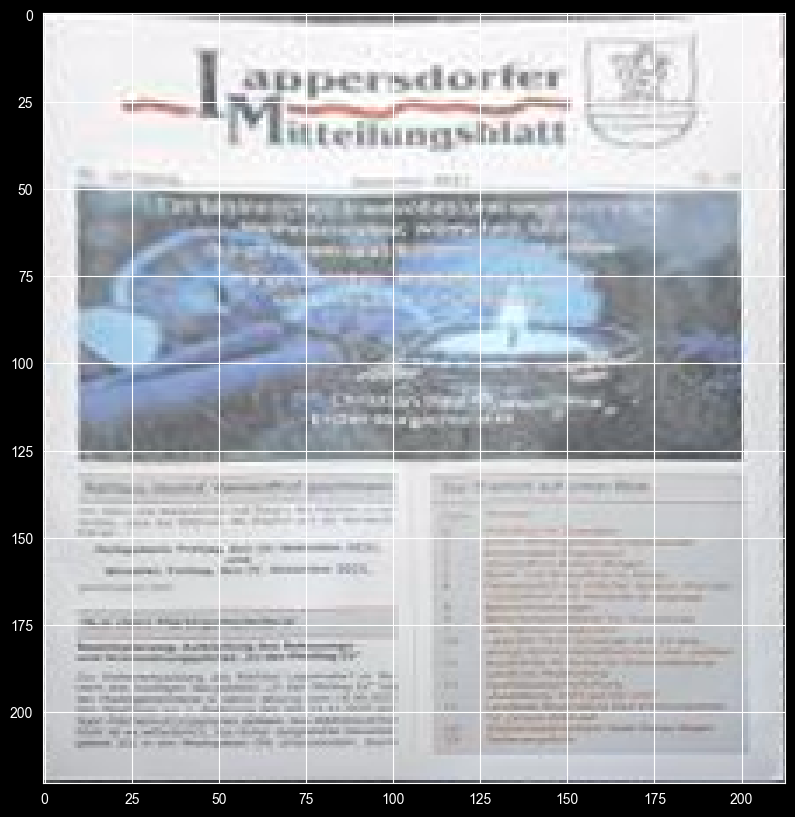

In [14]:
# Example usage:

x1, y1 = opt_top_left
x2, y2 = opt_top_right
x3, y3 = opt_bottom_left
x4, y4 = opt_bottom_right

quad = np.array([[x1,y1],[x2,y2],[x3,y3],[x4,y4]], dtype=np.float32)
result = rectify_document(img, quad)

plt.imshow(result)
# cv2.imwrite("rectified.png", result)